<a href="https://colab.research.google.com/github/Althaf12344/Ai-Skill-Project-VU/blob/main/week_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# AI Skill Gap Classification
# Decision Tree Classifier
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving AI_Skill_Gap_500_Students.xlsx to AI_Skill_Gap_500_Students.xlsx


In [3]:
df = pd.read_excel("AI_Skill_Gap_500_Students.xlsx")

In [4]:
df.head(10)

,Student_ID,Year,CGPA,Communication,ProblemSolving,Aptitude,CodingScore,Projects,Internships,Certifications,...,HTML,CSS,JavaScript,React,ML,DL,Git,Linux,Target_Role,Gap_Level
0,S001,1,8.82,60,59,48,48,5,0,4,...,0,1,1,0,1,1,1,1,AI Engineer,Low
1,S002,1,8.65,66,62,49,62,6,2,0,...,0,0,0,0,0,0,1,1,Software Engineer,Low
2,S003,3,8.68,47,87,54,72,0,1,6,...,0,0,1,0,0,0,1,1,Software Engineer,Low
3,S004,2,7.76,62,85,84,63,5,2,6,...,0,0,1,0,0,0,1,1,Software Engineer,Low
4,S005,4,7.01,60,92,75,68,5,3,4,...,0,1,1,1,0,0,1,1,Software Engineer,Low
5,S006,4,8.01,80,100,100,36,5,0,5,...,0,0,1,1,0,0,0,0,Data Analyst,Medium
6,S007,1,9.20,77,83,52,54,2,1,4,...,1,1,1,1,0,0,1,1,Web Developer,Low
7,S008,1,8.78,97,49,88,51,1,3,4,...,0,0,0,0,1,1,1,1,AI Engineer,Low
8,S009,4,6.94,49,66,41,64,4,1,0,...,0,0,1,1,1,1,1,0,AI Engineer,Low
9,S010,4,8.98,96,71,52,47,0,3,2,...,0,0,1,0,0,0,1,1,Software Engineer,Low


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 500
Columns : 23


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      500 non-null    object 
 1   Year            500 non-null    int64  
 2   CGPA            500 non-null    float64
 3   Communication   500 non-null    int64  
 4   ProblemSolving  500 non-null    int64  
 5   Aptitude        500 non-null    int64  
 6   CodingScore     500 non-null    int64  
 7   Projects        500 non-null    int64  
 8   Internships     500 non-null    int64  
 9   Certifications  500 non-null    int64  
 10  Python          500 non-null    int64  
 11  Java            500 non-null    int64  
 12  SQL             500 non-null    int64  
 13  HTML            500 non-null    int64  
 14  CSS             500 non-null    int64  
 15  JavaScript      500 non-null    int64  
 16  React           500 non-null    int64  
 17  ML              500 non-null    int

In [7]:
df.describe()

,Year,CGPA,Communication,ProblemSolving,Aptitude,CodingScore,Projects,Internships,Certifications,Python,Java,SQL,HTML,CSS,JavaScript,React,ML,DL,Git,Linux
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.542000,7.891600,72.446000,71.962000,69.402000,68.570000,2.934000,1.578000,2.920000,0.698000,0.390000,0.684000,0.400000,0.424000,0.412000,0.396000,0.402000,0.414000,0.738000,0.578000
std,1.160573,1.086125,16.178708,16.439497,17.616386,18.973589,2.009408,1.123584,2.067401,0.459585,0.488238,0.465379,0.490389,0.494685,0.492688,0.489554,0.490793,0.493042,0.440163,0.494373
min,1.000000,6.010000,45.000000,45.000000,40.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,6.970000,58.000000,57.000000,55.000000,52.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,7.865000,73.000000,71.000000,69.000000,69.000000,3.000000,2.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,4.000000,8.822500,87.000000,86.000000,84.000000,85.250000,5.000000,3.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,4.000000,9.790000,100.000000,100.000000,100.000000,100.000000,6.000000,3.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

,0
Student_ID,0
Year,0
CGPA,0
Communication,0
ProblemSolving,0
Aptitude,0
CodingScore,0
Projects,0
Internships,0
Certifications,0


In [9]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [10]:
df.columns

Index(['Student_ID', 'Year', 'CGPA', 'Communication', 'ProblemSolving',
       'Aptitude', 'CodingScore', 'Projects', 'Internships', 'Certifications',
       'Python', 'Java', 'SQL', 'HTML', 'CSS', 'JavaScript', 'React', 'ML',
       'DL', 'Git', 'Linux', 'Target_Role', 'Gap_Level'],
      dtype='object')

In [11]:
df.dtypes

,0
Student_ID,object
Year,int64
CGPA,float64
Communication,int64
ProblemSolving,int64
Aptitude,int64
CodingScore,int64
Projects,int64
Internships,int64
Certifications,int64


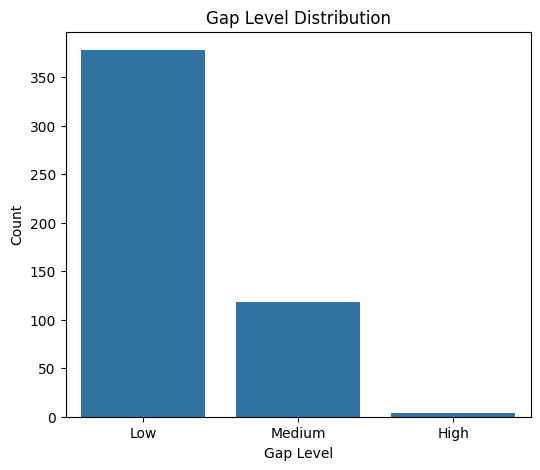

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Gap_Level"
)

plt.title("Gap Level Distribution")
plt.xlabel("Gap Level")
plt.ylabel("Count")

plt.show()

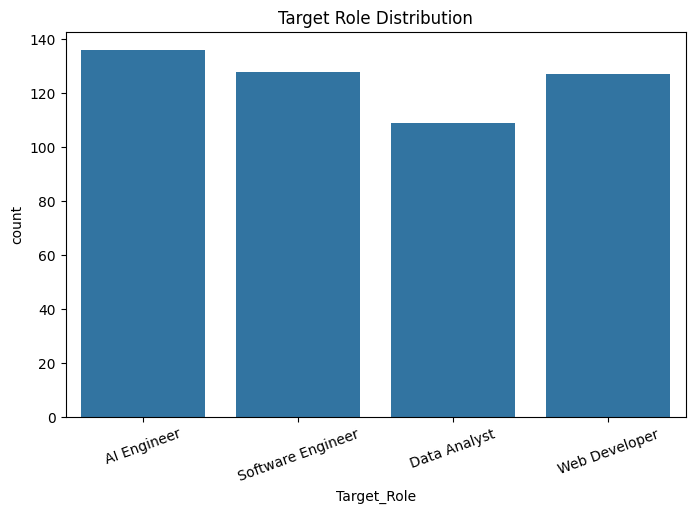

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Target_Role"
)

plt.xticks(rotation=20)

plt.title("Target Role Distribution")

plt.show()

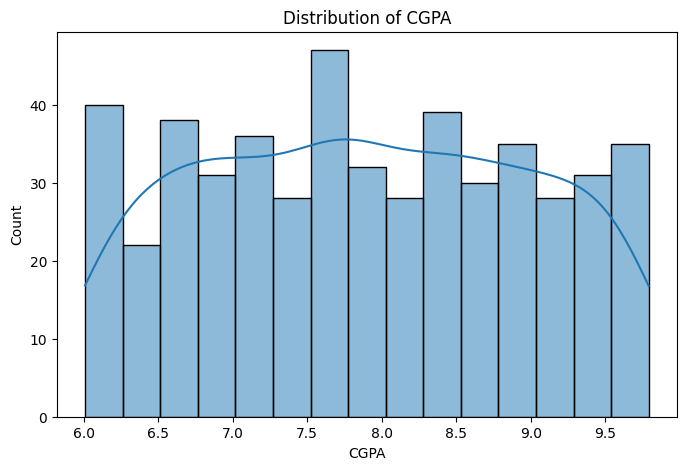

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["CGPA"],
    bins=15,
    kde=True
)

plt.title("Distribution of CGPA")

plt.show()

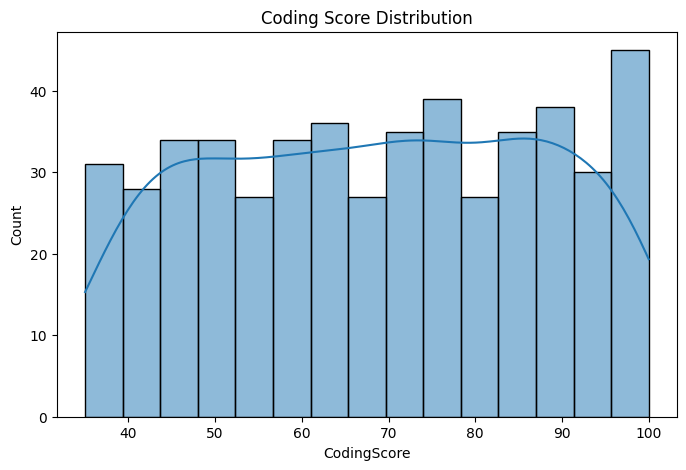

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["CodingScore"],
    bins=15,
    kde=True
)

plt.title("Coding Score Distribution")

plt.show()

In [19]:
# Numerical columns
numerical_columns = [
    'Year',
    'CGPA',
    'Communication',
    'ProblemSolving',
    'Aptitude',
    'CodingScore',
    'Projects',
    'Internships',
    'Certifications'
]

# Categorical columns
categorical_columns = [
    'Target_Role',
    'Gap_Level'
]

In [20]:
# Handle missing values in numerical columns
num_imputer = SimpleImputer(strategy='mean')

df[numerical_columns] = num_imputer.fit_transform(df[numerical_columns])

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
Student_ID        0
Year              0
CGPA              0
Communication     0
ProblemSolving    0
Aptitude          0
CodingScore       0
Projects          0
Internships       0
Certifications    0
Python            0
Java              0
SQL               0
HTML              0
CSS               0
JavaScript        0
React             0
ML                0
DL                0
Git               0
Linux             0
Target_Role       0
Gap_Level         0
dtype: int64


In [21]:
# Initialize Label Encoders
role_encoder = LabelEncoder()
gap_encoder = LabelEncoder()

# Encode Target Role
df['Target_Role'] = role_encoder.fit_transform(df['Target_Role'])

# Encode Target Variable
df['Gap_Level'] = gap_encoder.fit_transform(df['Gap_Level'])

print("Encoding Completed Successfully")

Encoding Completed Successfully


In [22]:
df.drop("Student_ID", axis=1, inplace=True)

In [23]:
df.head()

,Year,CGPA,Communication,ProblemSolving,Aptitude,CodingScore,Projects,Internships,Certifications,Python,...,HTML,CSS,JavaScript,React,ML,DL,Git,Linux,Target_Role,Gap_Level
0,1.0,8.82,60.0,59.0,48.0,48.0,5.0,0.0,4.0,1,...,0,1,1,0,1,1,1,1,0,1
1,1.0,8.65,66.0,62.0,49.0,62.0,6.0,2.0,0.0,1,...,0,0,0,0,0,0,1,1,2,1
2,3.0,8.68,47.0,87.0,54.0,72.0,0.0,1.0,6.0,1,...,0,0,1,0,0,0,1,1,2,1
3,2.0,7.76,62.0,85.0,84.0,63.0,5.0,2.0,6.0,1,...,0,0,1,0,0,0,1,1,2,1
4,4.0,7.01,60.0,92.0,75.0,68.0,5.0,3.0,4.0,1,...,0,1,1,1,0,0,1,1,2,1


In [24]:
# Features
X = df.drop("Gap_Level", axis=1)

# Target
y = df["Gap_Level"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features : (400, 21)
Testing Features  : (100, 21)

Training Labels : (400,)
Testing Labels  : (100,)


In [27]:
scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [28]:
X_train.head()

,Year,CGPA,Communication,ProblemSolving,Aptitude,CodingScore,Projects,Internships,Certifications,Python,...,SQL,HTML,CSS,JavaScript,React,ML,DL,Git,Linux,Target_Role
242,1.236989,1.431451,0.464567,-0.456049,1.392621,0.715406,0.042971,1.250707,1.510976,0,...,0,1,1,0,1,0,0,1,0,3
354,-1.349050,-0.093262,-1.382006,1.462203,0.029534,0.241802,-0.968114,-0.526496,1.022382,0,...,0,1,1,1,1,1,0,1,0,3
423,0.374976,-1.137459,-0.274062,-1.012961,0.881463,-0.863276,-0.968114,1.250707,-0.931992,1,...,1,1,1,0,0,1,0,0,0,1
198,-0.487037,-0.120984,-0.397167,-1.569873,-1.390349,-1.284259,-1.473656,-0.526496,1.510976,1,...,1,0,0,0,0,1,1,1,1,0
293,1.236989,-0.887960,0.833881,-1.198598,-1.674326,-0.600163,1.054056,-1.415098,-0.443399,1,...,1,0,1,0,1,1,1,1,1,0


In [29]:
processed_dataset = pd.concat([X, y], axis=1)

processed_dataset.to_csv(
    "Processed_AI_SkillGap_Dataset.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [30]:
print("Statistics After Scaling")

X_train[numerical_columns].describe()

Statistics After Scaling


,Year,CGPA,Communication,ProblemSolving,Aptitude,CodingScore,Projects,Internships,Certifications
count,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02
mean,7.105427e-17,4.707346e-16,-3.552714e-17,-2.398082e-16,-2.176037e-16,-4.440892e-17,-5.551115e-17,-3.996803e-17,-1.154632e-16
std,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00
min,-1.349050e+00,-1.728862e+00,-1.689768e+00,-1.693631e+00,-1.674326e+00,-1.757863e+00,-1.473656e+00,-1.415098e+00,-1.420586e+00
25%,-1.349050e+00,-8.209653e-01,-8.895864e-01,-8.892029e-01,-8.223960e-01,-8.632764e-01,-9.681136e-01,-5.264964e-01,-9.319922e-01
50%,3.749756e-01,-9.326159e-02,-2.785247e-02,-2.289527e-02,-2.726175e-02,-2.131222e-02,4.297110e-02,3.621051e-01,4.519490e-02
75%,1.236989e+00,8.908711e-01,8.954338e-01,8.588821e-01,8.246678e-01,9.258975e-01,1.054056e+00,1.250707e+00,1.022382e+00
max,1.236989e+00,1.754875e+00,1.695615e+00,1.709720e+00,1.733393e+00,1.662616e+00,1.559598e+00,1.250707e+00,1.510976e+00


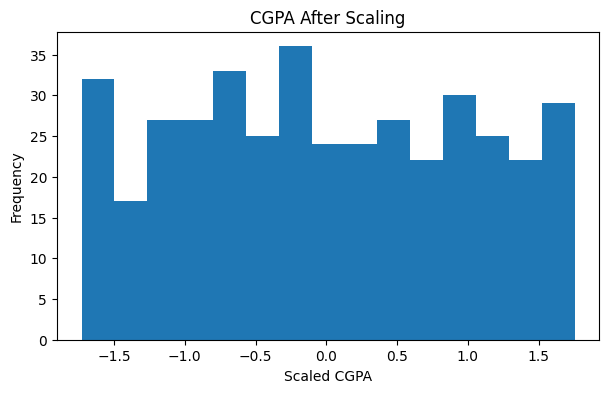

In [31]:
plt.figure(figsize=(7,4))

plt.hist(
    X_train["CGPA"],
    bins=15
)

plt.title("CGPA After Scaling")

plt.xlabel("Scaled CGPA")

plt.ylabel("Frequency")

plt.show()

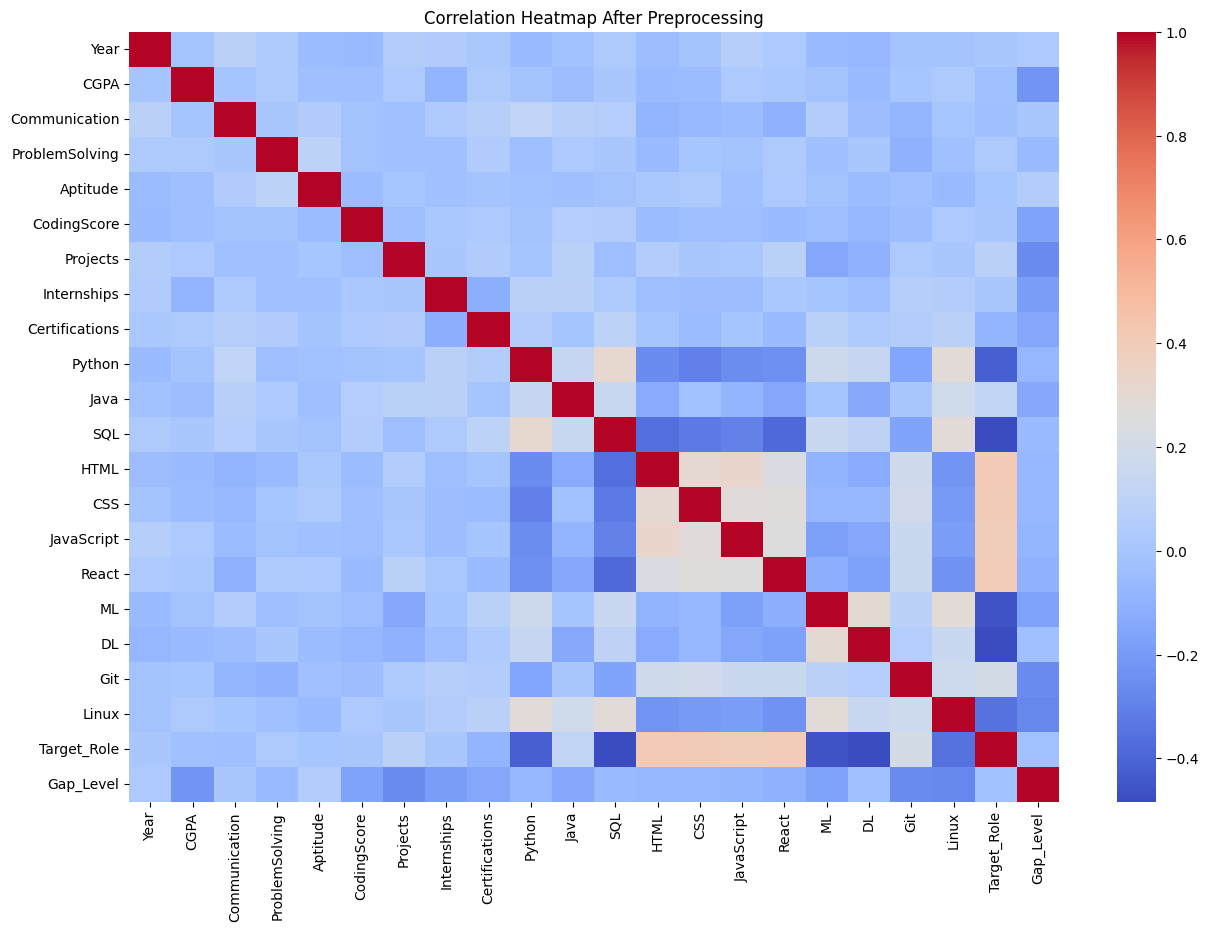

In [32]:
plt.figure(figsize=(15,10))

sns.heatmap(
    processed_dataset.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap After Preprocessing")

plt.show()

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [34]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [35]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [36]:
y_pred = dt_model.predict(X_test)

In [37]:
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy : {:.2f}%".format(accuracy*100))

Decision Tree Accuracy : 74.00%


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.87      0.79      0.83        76
           2       0.45      0.61      0.52        23

    accuracy                           0.74       100
   macro avg       0.44      0.47      0.45       100
weighted avg       0.76      0.74      0.75       100



In [39]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 0  0  1]
 [ 0 60 16]
 [ 0  9 14]]


In [40]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 0  0  1]
 [ 0 60 16]
 [ 0  9 14]]


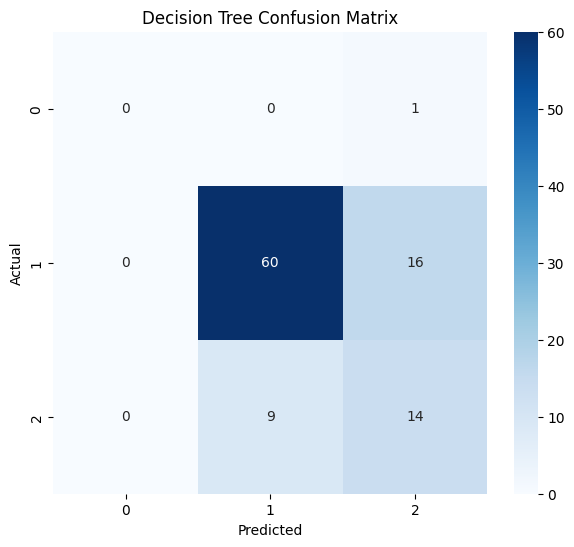

In [41]:
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [42]:
param_grid = {

    'criterion':['gini','entropy'],

    'max_depth':[3,5,8,10,12,None],

    'min_samples_split':[2,5,10],

    'min_samples_leaf':[1,2,4]

}

In [43]:
param_grid = {

    'criterion':['gini','entropy'],

    'max_depth':[3,5,8,10,12,None],

    'min_samples_split':[2,5,10],

    'min_samples_leaf':[1,2,4]

}